# SYDE 572 Assignment 1: Part 1
## Numerical Approach
### Algorithm A: Newton-Raphson Method
$$
f(x)=x^2+5
$$
$$
Points: (0,0), (−4,0), (−8,0), (2,0), (6,0)
$$
GOAL: to find the shortest distance from a point on the curve f(x) to each of these points.

A point on the curve is: $$Q=(x,f(x))$$

#### General Code (any point to any parabolic function)

Squared distance: 
$$
D(x)=(x-x_0)^2+(f(x)-y_0)^2
$$
$$
d(x)=\sqrt{D(x)}
$$

Taking the derivative of squared distance: 
$$
D'(x)=2(x-x_0)+2(f(x)-y_0)f'(x)
$$
$$
D''(x)=2+2(f'(x))^2+2(f(x)-y_0)f''(x)
$$

#### Method Explanation

Newton–Raphson is applied to the equation

$$
D'(x)=0
$$

Setting an initial guess of $x^{(0)}$, the estimate is updated using

$$
x^{(k+1)}
=
x^{(k)}
-
\frac{D'(x^{(k)})}{D''(x^{(k)})}
$$

Stop iterating when the change between consecutive estimates reaches the condition:

$$
\left|x^{(k+1)}-x^{(k)}\right|<10^{-7}
$$

$k$ = iteration number
$x_0$ = x coordinate of the given point

In [29]:
# import libraries
import math
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 

In [4]:
# reuseable Newton function 

def find_distance_newton(x0, y0, f, df, ddf, initial_guess=0.0, tolerance=1e-7, max_iter=100):

    # set initial guess 
    x = float(initial_guess)

    data = []
    converged = False

    for i in range(max_iter):

        # derivatives of function
        fx = f(x) 
        dfx = df(x)
        ddfx = ddf(x)

        # distance function derivatives
        D_prime = (2 * (x - x0) + 2 * (fx - y0) * dfx)
        D_double_prime = (2 + 2 * dfx**2 + 2 * (fx - y0) * ddfx)

        # Newton-Raphson update 
        next_x = x - (D_prime / D_double_prime)

        # distance calculation function
        D_x = (x - x0)**2 + (fx - y0)**2

        # save data for plotting
        data.append({
            "iteration_num": i,
            "x_current": x,
            "D(x)": D_x,
            "D'(x)": D_prime,
            "D''(x)": D_double_prime,
            "x_next": next_x,
            "step_size": abs(next_x - x)
        })

        step_size = abs(next_x - x)
        x = next_x

        # check stopping condition
        if step_size < tolerance:
            converged = True
            break

    # coordinates of the closest point on the curve
    x_opt = x
    y_opt = f(x_opt)

    # distance calculations
    distance_squared_min = ((x_opt - x0)**2 + (y_opt - y0)**2)
    distance_min = math.sqrt(distance_squared_min)

    return {
        "x_opt": x_opt,
        "y_opt": y_opt,
        "distance": distance_min,
        "squared_distance": distance_squared_min,
        "iterations": len(data),
        "converged": converged,
        "data": pd.DataFrame(data)
    }

For the given parabola,

$$
f(x)=x^2+5,
$$

the derivatives are

$$
f'(x)=2x
$$
$$
f''(x)=2
$$
These functions are defined below

In [1]:
def f(x):
    return x**2 + 5

def df(x):
    return 2 * x

def ddf(x):
    return 2

For the point $(-4,0)$

$$
x_0=-4,
\qquad
y_0=0.
$$

Choose the initial estimate as

$$
x^{(0)}=0.
$$

and continue until the change between two consecutive estimates is less than $10^{-7}$

In [6]:
x_negative_4 = find_distance_newton(
    x0=-4,
    y0=0,
    f=f,
    df=df,
    ddf=ddf,
    initial_guess=0.0,
    tolerance=1e-7
)

In [9]:
print("Converged:", x_negative_4["converged"])
print("Iterations:", x_negative_4["iterations"])
print("x*:", x_negative_4["x_opt"])
print("y*:", x_negative_4["y_opt"])
print("Minimum distance:", x_negative_4["distance"])

x_negative_4["data"]

Converged: True
Iterations: 4
x*: -0.35546969287483454
y*: 5.126358702552529
Minimum distance: 6.289845364298704


,iteration_num,x_current,D(x),D'(x),D''(x),x_next,step_size
0,0,0.000000,41.000000,8.000000e+00,22.000000,-0.363636,3.636364e-01
1,1,-0.363636,39.562940,-1.923366e-01,23.586777,-0.355482,8.154424e-03
2,2,-0.355482,39.562155,-2.879895e-04,23.516409,-0.355470,1.224632e-05
3,3,-0.355470,39.562155,-6.397425e-10,23.516304,-0.355470,2.720418e-11


The table above shows the current estimate, the squared distance, the first and second derivatives of the objective, the next estimate, and the step size.

From the algorithm, it is determined that the point on the curve closest to the point $(-4,0)$ is $(-0.355,5.126)$ which has a minimum distance of $6.289$.

Applying the same technique to all the other points:

$$
(0,0),\;(-4,0),\;(-8,0),\;(2,0),\;(6,0).
$$

The function and its derivatives do not change. Only the coordinates $x_0$ and $y_0$ change.

In [11]:
# define all points
points = [
    (0, 0),
    (-4, 0),
    (-8, 0),
    (2, 0),
    (6, 0)
]

# store results
newton_results = {}
result_rows = []

# loop through all the points and apply Newton-Raphon approach to each
for x0, y0 in points:

    result = find_distance_newton(
        x0=x0,
        y0=y0,
        f=f,
        df=df,
        ddf=ddf,
        initial_guess=0.0,
        tolerance=1e-7,
        max_iter=100
    )

    # save result 
    newton_results[(x0, y0)] = result

    result_rows.append({
        "point": f"({x0}, {y0})",
        "x_opt": result["x_opt"],
        "y_opt": result["y_opt"],
        "minimum_distance": result["distance"],
        "iterations": result["iterations"],
        "converged": result["converged"]
    })


# display summary results as a table
newton_table = pd.DataFrame(result_rows)
newton_table

,point,x_opt,y_opt,minimum_distance,iterations,converged
0,"(0, 0)",0.000000,5.000000,5.000000,1,True
1,"(-4, 0)",-0.355470,5.126359,6.289845,4,True
2,"(-8, 0)",-0.672078,5.451689,9.133420,5,True
3,"(2, 0)",0.180745,5.032669,5.351396,4,True
4,"(6, 0)",0.519904,5.270300,7.603125,4,True


The Newton–Raphson method converged for all five points using an initial guess of $x^{(0)}=0$ and tolerance $10^{-7}$. The results are displayed in the table above.

Next, we will plot how the Newton-Raphson estimate changes during each iteration.

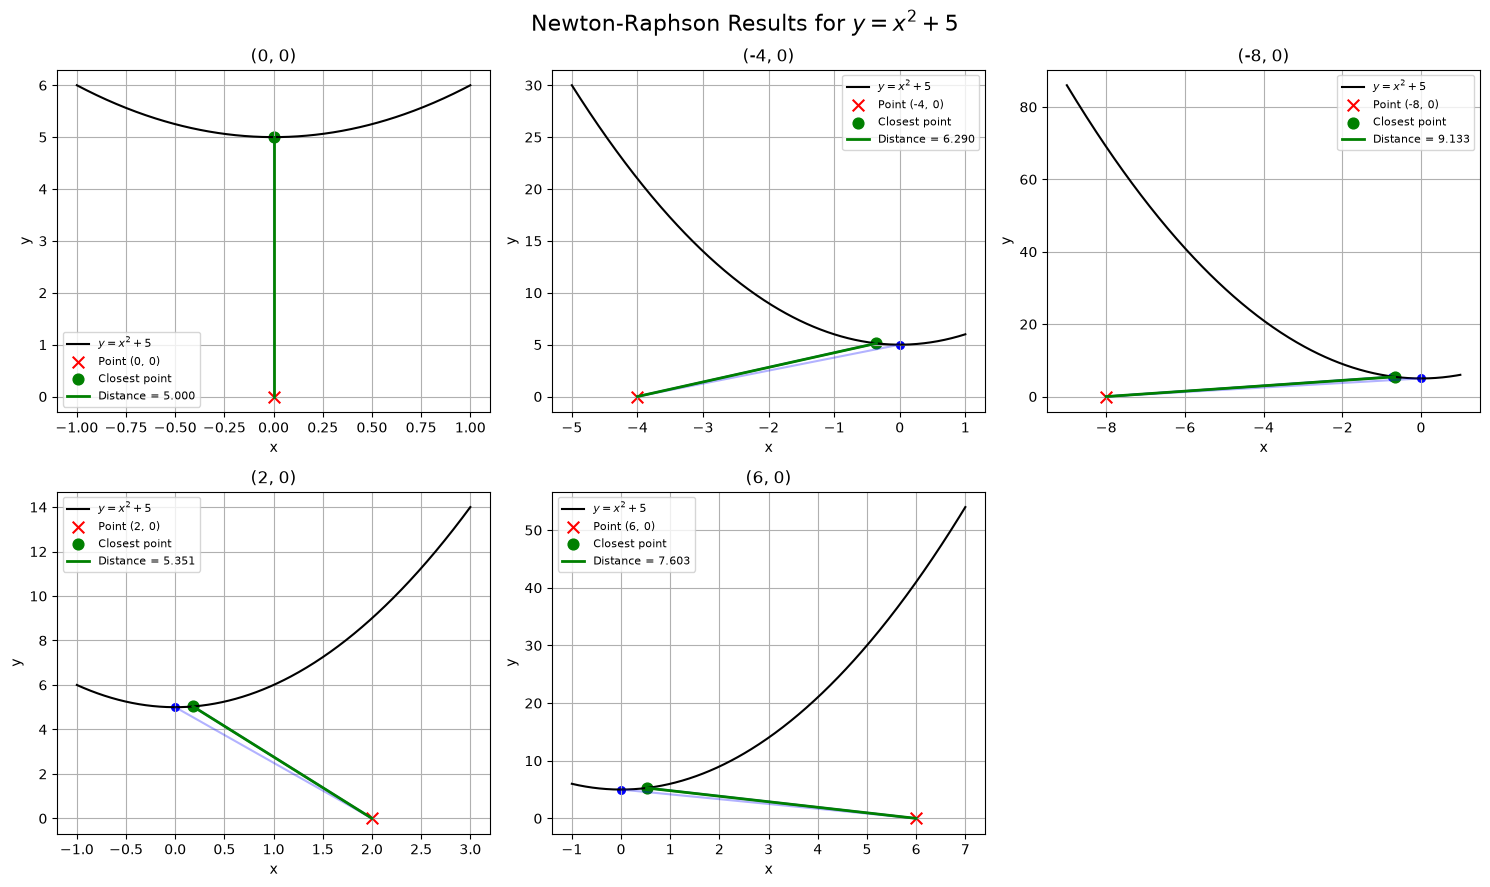

In [ ]:
# plot
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, point in enumerate(points):

    # get plotting data & result for each iteration
    x0, y0 = point
    result = newton_results[point]
    history = result["data"]

    x_opt = result["x_opt"]
    y_opt = result["y_opt"]

    iteration_x = history["x_current"].to_numpy()

    x_min = min(x0, x_opt, iteration_x.min()) - 1
    x_max = max(x0, x_opt, iteration_x.max()) + 1

    x_curve = np.linspace(x_min, x_max, 400)
    y_curve = f(x_curve)

    ax = axes[i]

    # plot f(x)
    ax.plot(
        x_curve,
        y_curve,
        color="black",
        label=r"$y=x^2+5$"
    )

    # plot the given point
    ax.scatter(
        x0,
        y0,
        color="red",
        marker="x",
        s=70,
        label=f"Point ({x0}, {y0})"
    )

    # plot the intermediate points per iteration
    for _, row in history.iterrows():

        current_x = row["x_current"]
        current_y = f(current_x)

        ax.scatter(
            current_x,
            current_y,
            color="blue",
            s=30
        )

        ax.plot(
            [x0, current_x],
            [y0, current_y],
            color="blue",
            alpha=0.3
        )

    # plot the final closest point
    ax.scatter(
        x_opt,
        y_opt,
        color="green",
        s=60,
        label="Closest point"
    )

    # plot the final minimum distance line
    ax.plot(
        [x0, x_opt],
        [y0, y_opt],
        color="green",
        linewidth=2,
        label=f"Distance = {result['distance']:.3f}"
    )

    # label axes 
    ax.set_title(f"({x0}, {y0})")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.grid(True)
    ax.legend(fontsize=8)


# Remove the unused sixth subplot.
fig.delaxes(axes[5])

# plot cosmetic changes
fig.suptitle(
    "Newton-Raphson Results for $y=x^2+5$",
    fontsize=16
)

plt.tight_layout()
plt.show()

### Extension to Non-Polynomial functions 
To demonstrate that this approach also works for non-polynomial function, an exponential function will be used. The same function can be used however the derivatives of this function need to be updated as follows: 

$$
f(x)=e^{2x}+1
$$

$$
f'(x)=2e^{2x}
$$

$$
f''(x)=4e^{2x}
$$

A walkthrough of this sample f(x) and point (1,0) is shown below.

In [18]:
# exponential function (non-polynomial)
def f_exp(x):
    return np.exp(2 * x) + 1

# derivatives
def df_exp(x):
    return 2 * np.exp(2 * x)

def ddf_exp(x):
    return 4 * np.exp(2 * x)

In [20]:
exponential_result = find_distance_newton(
    x0=1,
    y0=0,
    f=f_exp,
    df=df_exp,
    ddf=ddf_exp,
    initial_guess=0.0,
    tolerance=1e-7,
    max_iter=100
)

print("Converged:", exponential_result["converged"])
print("Iterations:", exponential_result["iterations"])
print("x*:", exponential_result["x_opt"])
print("y*:", exponential_result["y_opt"])
print("Minimum distance:", exponential_result["distance"])

exponential_result["data"]

Converged: True
Iterations: 6
x*: -0.3784351439989231
y*: 1.4691323810499066
Minimum distance: 2.0145553850069997


,iteration_num,x_current,D(x),D'(x),D''(x),x_next,step_size
0,0,0.000000,5.000000,6.000000e+00,26.000000,-0.230769,2.307692e-01
1,1,-0.230769,4.172714,1.648893e+00,13.399221,-0.353828,1.230589e-01
2,2,-0.353828,4.061296,2.349341e-01,9.827978,-0.377733,2.390462e-02
3,3,-0.377733,4.058436,6.519803e-03,9.289606,-0.378435,7.018385e-04
4,4,-0.378435,4.058433,5.325998e-06,9.274435,-0.378435,5.742666e-07
5,5,-0.378435,4.058433,3.559819e-12,9.274422,-0.378435,3.838596e-13


### Algorithm B: Golden Section Search Method
$$
f(x)=x^2+5
$$
$$
Points: (0,0), (−4,0), (−8,0), (2,0), (6,0)
$$
GOAL: to find the shortest distance from a point on the curve f(x) to each of these points.

A point on the curve is: $$Q=(x,f(x))$$

#### General Code

Squared distance: 
$$
D(x)=(x-x_0)^2+(f(x)-y_0)^2
$$
$$
d(x)=\sqrt{D(x)}.
$$

For this method, an interval $[L,U]$ is set, which must contain a minimum. A constant is also set, which is

$$
r=\frac{3-\sqrt{5}}{2}\approx0.381966.
$$

For the current interval $[L,U]$, two points within this interval are calculated, using the boundaries and the constant:

$$
x_1=L+r(U-L)
$$

$$
x_2=U-r(U-L)
$$

If $D(x_1)<D(x_2)$, the interval becomes $[L,x_2]$
If $D(x_1)>D(x_2)$, the interval becomes $[x_1,U]$

And another iteration is done

Stop iterating when:

$$
U-L\leq10^{-7}.
$$

In [21]:
# reuseable Golden Section Search function 

def find_distance_golden(x0, y0, f, lower, upper, tolerance=1e-7, max_iter=1000):

    # extra check to make sure interval is valid
    if lower >= upper:
        raise ValueError(
            "The search interval must satisfy lower < upper."
        )

    # update the current bounds
    L = float(lower)
    U = float(upper)

    # calculate the Golden Section constant
    r = (3 - math.sqrt(5)) / 2

    # distance calculation 
    def dist_sq(x):
        return (x - x0)**2 + (f(x) - y0)**2

    # calculate interior points
    x1 = L + r * (U - L)
    x2 = U - r * (U - L)

    # determine squared distance of each x value
    D_x1 = dist_sq(x1)
    D_x2 = dist_sq(x2)

    data = []
    converged = False

    for i in range(max_iter):

        # save data
        data.append({
            "iteration_num": i,
            "lower": L,
            "upper": U,
            "interval_width": U - L,
            "x1": x1,
            "D(x1)": D_x1,
            "x2": x2,
            "D(x2)": D_x2,
            "best_x": x1 if D_x1 < D_x2 else x2
        })

        # stopping condition
        if U - L <= tolerance:
            converged = True
            break

        # update the next interval based on previous results
        if D_x1 < D_x2:
            U = x2
            x2 = x1
            D_x2 = D_x1

            # calculate new x1 & distance
            x1 = L + r * (U - L)
            D_x1 = dist_sq(x1)

        else:
            L = x1
            x1 = x2
            D_x1 = D_x2

            # calculate new x2 & distance
            x2 = U - r * (U - L)
            D_x2 = dist_sq(x2)

    # determine optimal x (midpoint between bounds)
    x_opt = (L + U) / 2
    y_opt = f(x_opt)

    squared_distance_min = dist_sq(x_opt)
    distance_min = math.sqrt(squared_distance_min)

    return {
        "x_opt": x_opt,
        "y_opt": y_opt,
        "distance": distance_min,
        "squared_distance": squared_distance_min,
        "iterations": len(data),
        "converged": converged,
        "lower": L,
        "upper": U,
        "data": pd.DataFrame(data)
    }

For the given parabola,

$$
f(x)=x^2+5,
$$

the function is defined below.

In [22]:
def f(x):
    return x**2 + 5

For the point $(-4,0)$

the squared-distance objective function is

$$
D(x)=(x+4)^2+(x^2+5)^2
$$

Choose the initial interval as 

$$
[L,U]=[-1,0]
$$

because this interval contains the unique minimum of the squared distance objective function. Continue until the stopping condition. 

In [25]:
golden_x_negative_4 = find_distance_golden(
    x0=-4,
    y0=0,
    f=f,
    lower=-1,
    upper=0,
    tolerance=1e-7,
    max_iter=1000
)

print("Converged:", golden_x_negative_4["converged"])
print("Iterations:", golden_x_negative_4["iterations"])
print("Final interval:", (
    golden_x_negative_4["lower"],
    golden_x_negative_4["upper"]
))
print("x*:", golden_x_negative_4["x_opt"])
print("y*:", golden_x_negative_4["y_opt"])
print("Minimum distance:", golden_x_negative_4["distance"])

Converged: True
Iterations: 35
Final interval: (-0.355469735798082, -0.3554696573792749)
x*: -0.35546969658867844
y*: 5.126358705192847
Minimum distance: 6.289845364298705


To get to the result within our set tolerance, 35 iterations had to be completed. The following tables will show the first 10 iterations and the final 5, respectively. 

In [27]:
golden_x_negative_4["data"].head(10)

,iteration_num,lower,upper,interval_width,x1,D(x1),x2,D(x2),best_x
0,0,-1.000000,0.000000,1.000000,-0.618034,40.403252,-0.381966,39.570437,-0.381966
1,1,-0.618034,0.000000,0.618034,-0.381966,39.570437,-0.236068,39.727571,-0.381966
2,2,-0.618034,-0.236068,0.381966,-0.472136,39.724638,-0.381966,39.570437,-0.381966
3,3,-0.472136,-0.236068,0.236068,-0.381966,39.570437,-0.326238,39.572167,-0.381966
4,4,-0.472136,-0.326238,0.145898,-0.416408,39.606154,-0.381966,39.570437,-0.381966
5,5,-0.416408,-0.326238,0.090170,-0.381966,39.570437,-0.360680,39.562474,-0.360680
6,6,-0.381966,-0.326238,0.055728,-0.360680,39.562474,-0.347524,39.562896,-0.360680
7,7,-0.381966,-0.347524,0.034442,-0.368810,39.564251,-0.360680,39.562474,-0.360680
8,8,-0.368810,-0.347524,0.021286,-0.360680,39.562474,-0.355655,39.562155,-0.355655
9,9,-0.360680,-0.347524,0.013156,-0.355655,39.562155,-0.352549,39.562255,-0.355655


In [ ]:
golden_x_negative_4["data"].tail(5)

,iteration_num,lower,upper,interval_width,x1,D(x1),x2,D(x2),best_x
30,30,-0.35547,-0.35547,5.374905e-07,-0.35547,39.562155,-0.35547,39.562155,-0.35547
31,31,-0.35547,-0.35547,3.321874e-07,-0.35547,39.562155,-0.35547,39.562155,-0.35547
32,32,-0.35547,-0.35547,2.053031e-07,-0.35547,39.562155,-0.35547,39.562155,-0.35547
33,33,-0.35547,-0.35547,1.268843e-07,-0.35547,39.562155,-0.35547,39.562155,-0.35547
34,34,-0.35547,-0.35547,7.841881e-08,-0.35547,39.562155,-0.35547,39.562155,-0.35547


From this, it is determined that the point on the curve closest to the point $(-4,0)$ is $(-0.355,5.126)$ which has a minimum distance of $6.289$. This matches up with what was found in the Newton-Raphson method. 

Applying the same technique to all the other points:

$$
(0,0),\;(-4,0),\;(-8,0),\;(2,0),\;(6,0).
$$

Different initial intervals are selected for each point, because the closest point lies on the negative side of the parabola for negative input points and on the positive side for positive input points.

In [28]:
# dictionary of the points and their corresponding starting interval 
search_intervals = {
    (0, 0): (-1, 0.5),
    (-4, 0): (-1, 0),
    (-8, 0): (-1, 0),
    (2, 0): (0, 1),
    (6, 0): (0, 1)
}

# store results 
golden_results = {}
golden_rows = []

# loop through all the points & apply the Golden-Section Search to each
for x0, y0 in points:

    # determine the interval defined earlier
    lower, upper = search_intervals[(x0, y0)]

    result = find_distance_golden(
        x0=x0,
        y0=y0,
        f=f,
        lower=lower,
        upper=upper,
        tolerance=1e-7,
        max_iter=1000
    )

    # Ssave result
    golden_results[(x0, y0)] = result

    golden_rows.append({
        "point": f"({x0}, {y0})",
        "initial_interval": f"[{lower}, {upper}]",
        "x_opt": result["x_opt"],
        "y_opt": result["y_opt"],
        "minimum_distance": result["distance"],
        "iterations": result["iterations"],
        "converged": result["converged"]
    })


# display summary results as a table 
golden_table = pd.DataFrame(golden_rows)
golden_table

,point,initial_interval,x_opt,y_opt,minimum_distance,iterations,converged
0,"(0, 0)","[-1, 0.5]",-6.395797e-09,5.000000,5.000000,36,True
1,"(-4, 0)","[-1, 0]",-3.554697e-01,5.126359,6.289845,35,True
2,"(-8, 0)","[-1, 0]",-6.720781e-01,5.451689,9.133420,35,True
3,"(2, 0)","[0, 1]",1.807446e-01,5.032669,5.351396,35,True
4,"(6, 0)","[0, 1]",5.199037e-01,5.270300,7.603125,35,True


The Golden Section Search method converged for all five points and the algorithm produced the same minimum distance as the Newton-Raphson method. 

Next, we will plot how the Golden Section Search estimate changes during each iteration.

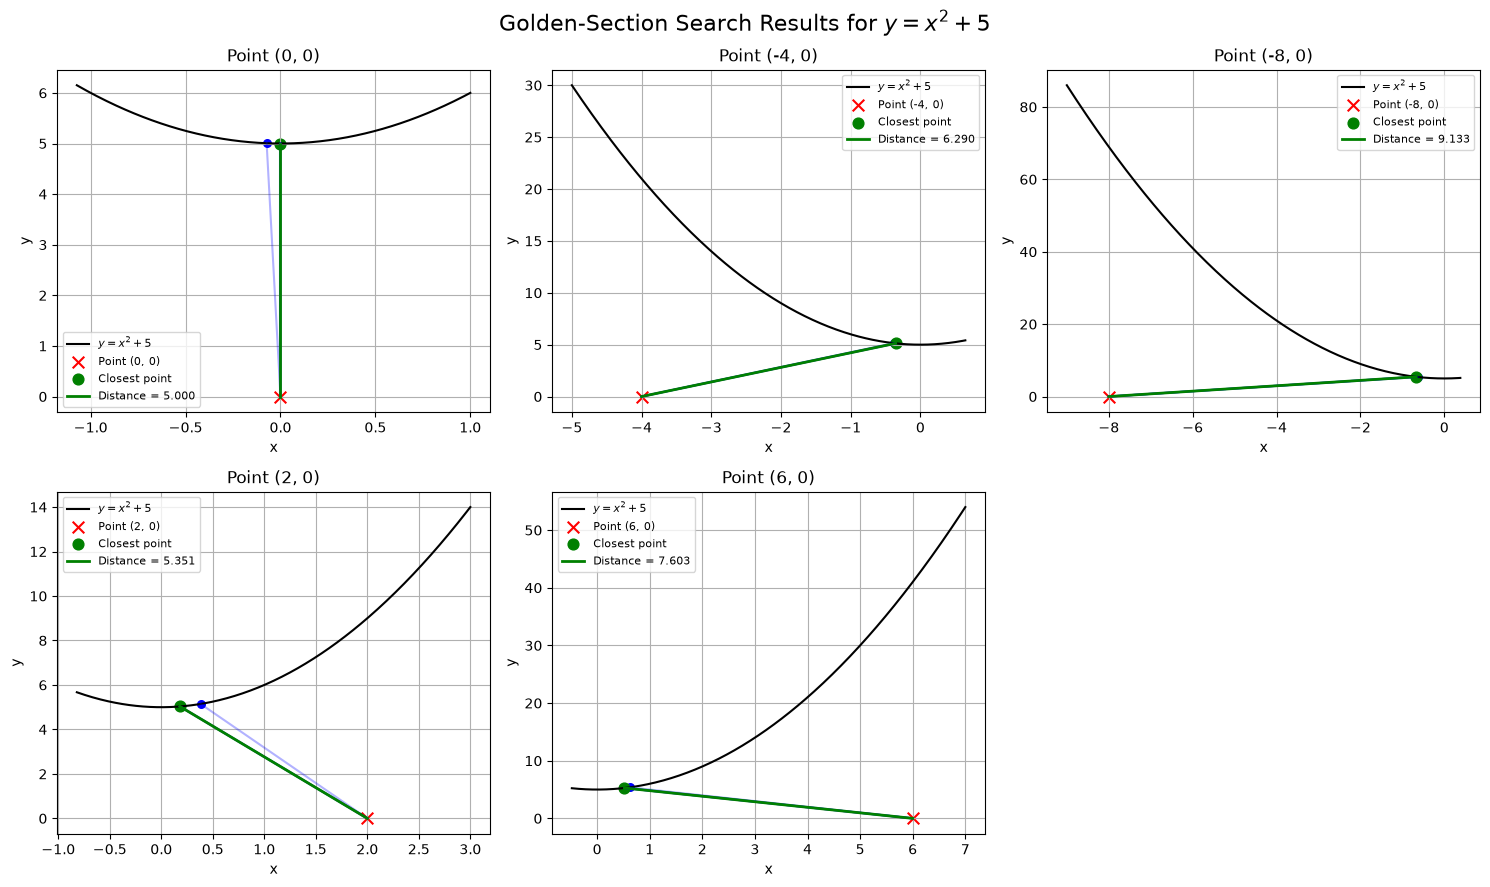

In [30]:
#plot
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

axes = axes.flatten()

for i, point in enumerate(points):

    # get plotting data & result for each iteration 
    x0, y0 = point
    result = golden_results[point]
    history = result["data"]

    x_opt = result["x_opt"]
    y_opt = result["y_opt"]

    # choose 6 iterations
    selected_rows = np.linspace(
        0,
        len(history) - 1,
        6,
        dtype=int
    )

    sampled_history = history.iloc[selected_rows]

    candidate_x_values = sampled_history["best_x"].to_numpy()

    x_min = min(x0, x_opt, candidate_x_values.min()) - 1
    x_max = max(x0, x_opt, candidate_x_values.max()) + 1

    x_curve = np.linspace(x_min, x_max, 400)
    y_curve = f(x_curve)

    ax = axes[i]

    # plot f(x)
    ax.plot(
        x_curve,
        y_curve,
        color="black",
        label=r"$y=x^2+5$"
    )

    # plot the given point
    ax.scatter(
        x0,
        y0,
        color="red",
        marker="x",
        s=70,
        label=f"Point ({x0}, {y0})"
    )

    # plot the intermediate points per iteration 
    for _, row in sampled_history.iterrows():

        candidate_x = row["best_x"]
        candidate_y = f(candidate_x)

        ax.scatter(
            candidate_x,
            candidate_y,
            color="blue",
            s=30
        )

        ax.plot(
            [x0, candidate_x],
            [y0, candidate_y],
            color="blue",
            alpha=0.3
        )

    # plot the final closest point
    ax.scatter(
        x_opt,
        y_opt,
        color="green",
        s=60,
        label="Closest point"
    )

    # plot the final minimum distance line
    ax.plot(
        [x0, x_opt],
        [y0, y_opt],
        color="green",
        linewidth=2,
        label=f"Distance = {result['distance']:.3f}"
    )

    ax.set_title(f"Point ({x0}, {y0})")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.grid(True)
    ax.legend(fontsize=8)


# Remove the unused subplot.
fig.delaxes(axes[5])

# plot cosmetic changes
fig.suptitle(
    "Golden-Section Search Results for $y=x^2+5$",
    fontsize=16
)

plt.tight_layout()
plt.show()

### Extension to Non-Polynomial functions 
To demonstrate that this approach also works for non-polynomial function, an exponential function will be used:

$$
f(x)=e^{2x}+1
$$

A walkthrough of this sample f(x) and point (1,0) is shown below.

The search interval is selected as

$$
[-2,1]
$$

since this interval contains the minimum of the squared-distance objective.

In [32]:
#f_exp defined in Approach A 
golden_exponential = find_distance_golden(
    x0=1,
    y0=0,
    f=f_exp,
    lower=-2,
    upper=1,
    tolerance=1e-7,
    max_iter=1000
)

print("Converged:", golden_exponential["converged"])
print("Iterations:", golden_exponential["iterations"])
print("x*:", golden_exponential["x_opt"])
print("y*:", golden_exponential["y_opt"])
print("Minimum distance:", golden_exponential["distance"])

golden_exponential["data"].head(10)

Converged: True
Iterations: 37
x*: -0.3784351320505546
y*: 1.4691323922606399
Minimum distance: 2.0145553850069997


,iteration_num,lower,upper,interval_width,x1,D(x1),x2,D(x2),best_x
0,0,-2.000000,1.000000,3.000000,-0.854102,4.832906,-0.145898,4.364815,-0.145898
1,1,-0.854102,1.000000,1.854102,-0.145898,4.364815,0.291796,8.299417,-0.145898
2,2,-0.854102,0.291796,1.145898,-0.416408,4.064929,-0.145898,4.364815,-0.416408
3,3,-0.854102,-0.145898,0.708204,-0.583592,4.227120,-0.416408,4.064929,-0.416408
4,4,-0.583592,-0.145898,0.437694,-0.416408,4.064929,-0.313082,4.079300,-0.416408
5,5,-0.583592,-0.313082,0.270510,-0.480267,4.103017,-0.416408,4.064929,-0.416408
6,6,-0.480267,-0.313082,0.167184,-0.416408,4.064929,-0.376941,4.058444,-0.376941
7,7,-0.416408,-0.313082,0.103326,-0.376941,4.058444,-0.352549,4.061605,-0.376941
8,8,-0.416408,-0.352549,0.063859,-0.392016,4.059280,-0.376941,4.058444,-0.376941
9,9,-0.392016,-0.352549,0.039467,-0.376941,4.058444,-0.367624,4.058980,-0.376941


#### Conclusion
For all five points, both approaches produce the same optimal x and y value and minimum distances.